## Task 1: Load Dataset
- Use a dataset such as Iris dataset (from sklearn) or load any CSV file.
## Task 2: Exploratory Data Analysis (EDA)
- Display dataset information, shape, and statistical summary.
- Plot distributions of features (histograms / pairplot).
- Visualize correlations
## Task 3: Data Preprocessing
- Split dataset into training and testing sets (e.g., 70% train, 30% test).
## Task 4: Build Decision Tree Classifier
- Train the model using DecisionTreeClassifier.
## Task 5: Model Evaluation
- Make predictions on the test data.
- Evaluate using:
- Accuracy Score
- Confusion Matrix
- Classification Report
## Task 6: Experimentation
- Change parameters (criterion = "gini" vs "entropy", max_depth, min_samples_split).
- Compare results and observe overfitting vs underfitting.


In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
iris = load_iris(as_frame=True)
df = iris.frame

X = iris.data
y = iris.target
target_names = iris.target_names

In [5]:
print("--- Dataset Shape ---")
print(f"Shape: {df.shape}")

print("\n--- Dataset Info ---")
df.info()

print("\n--- Statistical Summary ---")
print(df.describe())

--- Dataset Shape ---
Shape: (150, 5)

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB

--- Statistical Summary ---
       sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)      target
count         150.000000        150.000000         150.000000        150.000000  150.000000
mean            5.843333          3.057333           3.758000          1.199333    1.000000
std             0.828066          0.435866           1.765298          0.762238    0.819232
min             4.300000          2.000000           

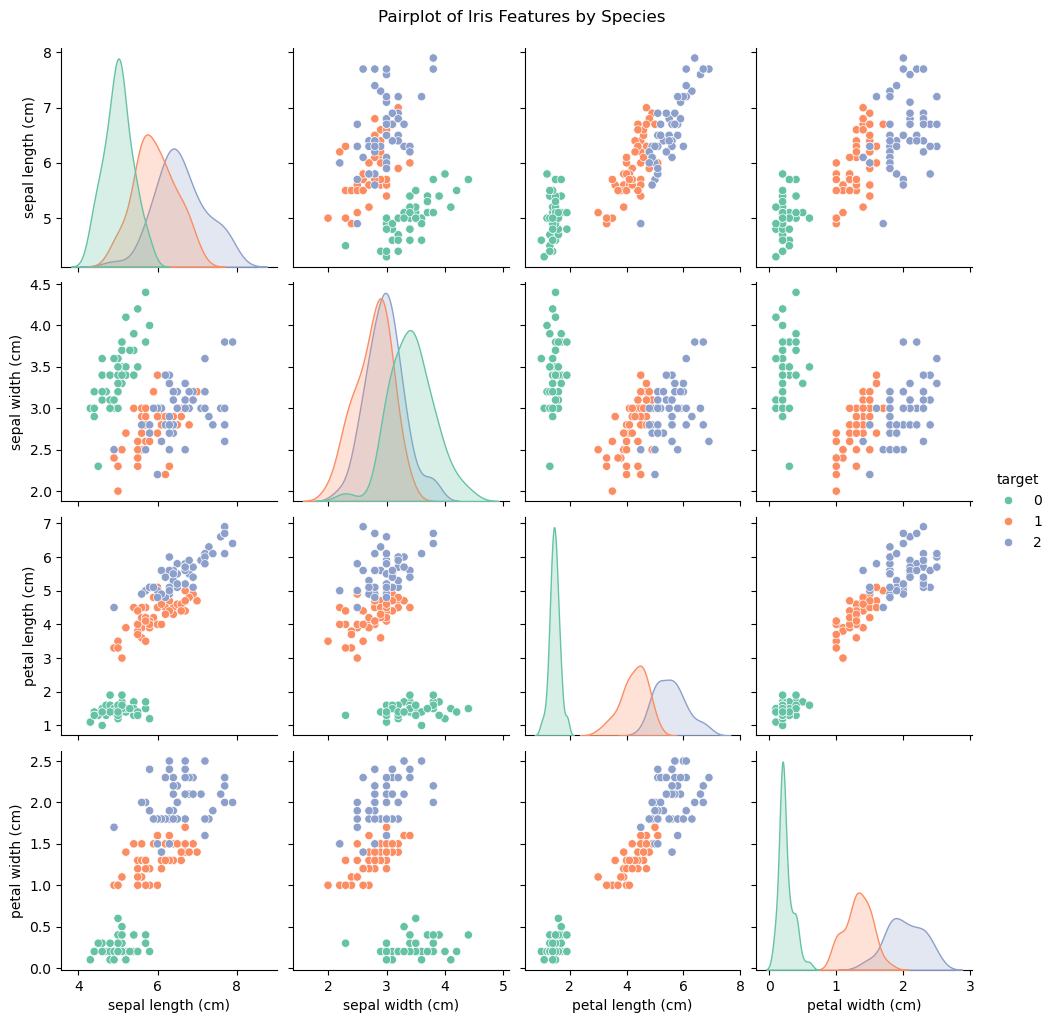

In [6]:
sns.pairplot(df, hue="target", palette="Set2", diag_kind="kde")
plt.suptitle("Pairplot of Iris Features by Species", y=1.02)
plt.show()

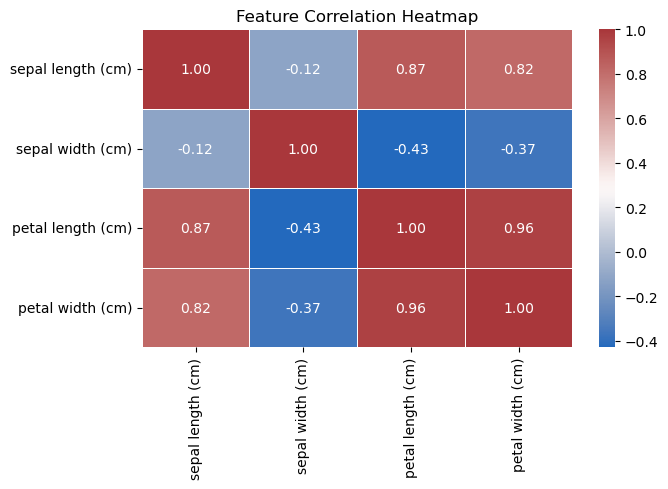

In [7]:
plt.figure(figsize=(7, 5))
feature_corr = df[iris.feature_names].corr()
sns.heatmap(feature_corr, annot=True, cmap="vlag", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

In [9]:
dt_base = DecisionTreeClassifier(random_state=42)
dt_base.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [10]:
y_pred = dt_base.predict(X_test)

print("\n--- Baseline Model Evaluation ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=target_names))


--- Baseline Model Evaluation ---
Accuracy Score: 0.9333

--- Classification Report ---
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       1.00      0.80      0.89        15
   virginica       0.83      1.00      0.91        15

    accuracy                           0.93        45
   macro avg       0.94      0.93      0.93        45
weighted avg       0.94      0.93      0.93        45



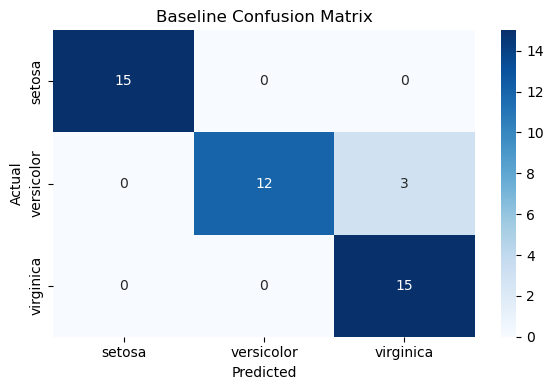

In [11]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=target_names,
    yticklabels=target_names,
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Baseline Confusion Matrix")
plt.tight_layout()
plt.show()


--- Hyperparameter Experimentation Results ---
                     Config Criterion max_depth  min_samples_split  Train Accuracy  Test Accuracy        Observed State
      Underfitted (Shallow)      gini         1                  2          0.6667         0.6667          Underfitting
         Balanced (Depth=3)      gini         3                  2          0.9810         0.9778           Optimal Fit
          Entropy Criterion   entropy         3                  2          0.9810         0.9333           Optimal Fit
    Overfitted (Full Depth)      gini      None                  2          1.0000         0.9333 Potential Overfitting
High Min-Split (Restricted)      gini      None                 40          0.9714         0.8889           Optimal Fit


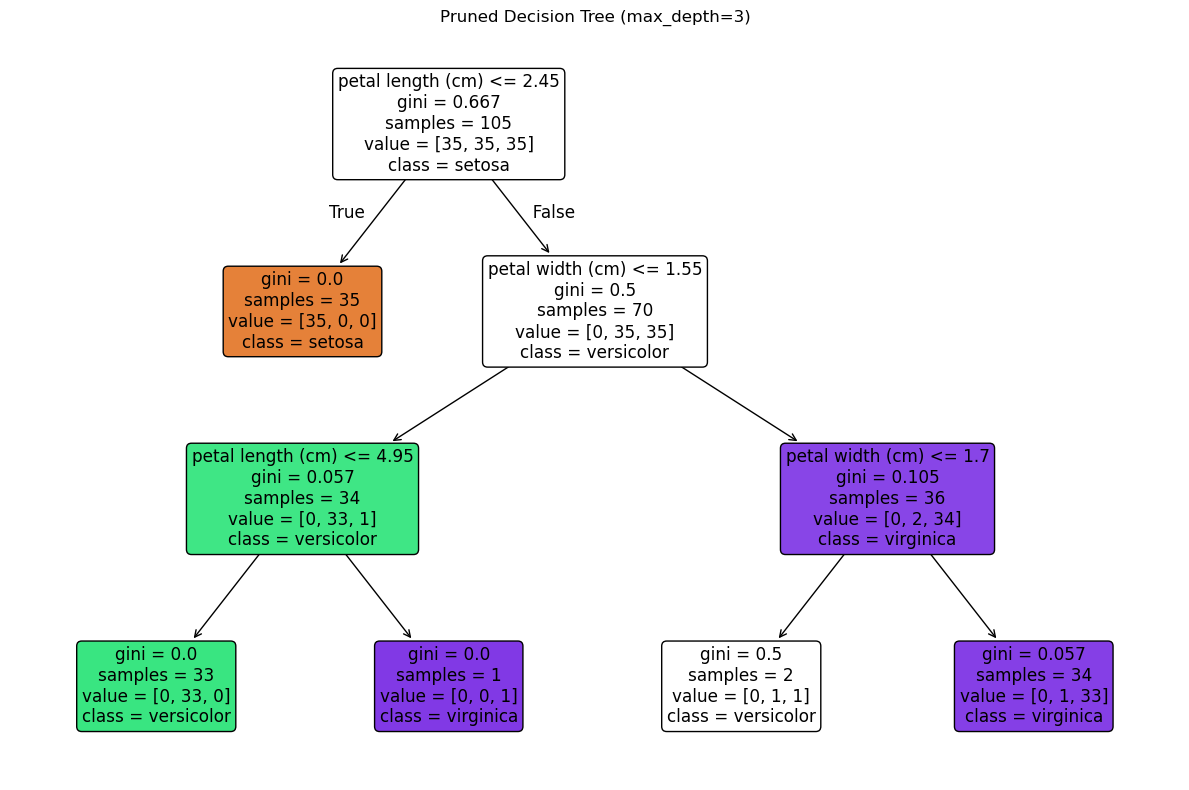

In [12]:
experiments = [
    {
        "name": "Underfitted (Shallow)",
        "params": {"criterion": "gini", "max_depth": 1, "min_samples_split": 2},
    },
    {
        "name": "Balanced (Depth=3)",
        "params": {"criterion": "gini", "max_depth": 3, "min_samples_split": 2},
    },
    {
        "name": "Entropy Criterion",
        "params": {"criterion": "entropy", "max_depth": 3, "min_samples_split": 2},
    },
    {
        "name": "Overfitted (Full Depth)",
        "params": {"criterion": "gini", "max_depth": None, "min_samples_split": 2},
    },
    {
        "name": "High Min-Split (Restricted)",
        "params": {"criterion": "gini", "max_depth": None, "min_samples_split": 40},
    },
]

results = []

for exp in experiments:
    clf = DecisionTreeClassifier(**exp["params"], random_state=42)
    clf.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, clf.predict(X_train))
    test_acc = accuracy_score(y_test, clf.predict(X_test))

    results.append(
        {
            "Config": exp["name"],
            "Criterion": exp["params"]["criterion"],
            "max_depth": str(exp["params"]["max_depth"]),
            "min_samples_split": exp["params"]["min_samples_split"],
            "Train Accuracy": round(train_acc, 4),
            "Test Accuracy": round(test_acc, 4),
            "Observed State": (
                "Underfitting"
                if train_acc < 0.75
                else (
                    "Potential Overfitting"
                    if (train_acc == 1.0 and test_acc < train_acc)
                    else "Optimal Fit"
                )
            ),
        }
    )

results_df = pd.DataFrame(results)
print("\n--- Hyperparameter Experimentation Results ---")
print(results_df.to_string(index=False))

# Plot the tree structure of the balanced model
plt.figure(figsize=(12, 8))
balanced_model = DecisionTreeClassifier(criterion="gini", max_depth=3, random_state=42)
balanced_model.fit(X_train, y_train)
plot_tree(
    balanced_model,
    feature_names=iris.feature_names,
    class_names=list(target_names),
    filled=True,
    rounded=True,
)
plt.title("Pruned Decision Tree (max_depth=3)")
plt.tight_layout()
plt.show()